In [1]:
import piplite
await piplite.install('seaborn')

In [2]:
import numpy as nm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data Cleaning

In [20]:
df = pd.read_csv("test.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 24.4+ KB


In [22]:
df.tail()
    

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
362,LP002971,Male,Yes,3+,Not Graduate,Yes,4009,1777,113.0,360.0,1.0,Urban
363,LP002975,Male,Yes,0,Graduate,No,4158,709,115.0,360.0,1.0,Urban
364,LP002980,Male,No,0,Graduate,No,3250,1993,126.0,360.0,NaN,Semiurban
365,LP002986,Male,Yes,0,Graduate,No,5000,2393,158.0,360.0,1.0,Rural
366,LP002989,Male,No,0,Graduate,Yes,9200,0,98.0,180.0,1.0,Rural


In [23]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,362.000000,361.000000,338.000000
mean,4805.599455,1569.577657,136.132597,342.537396,0.825444
std,4910.685399,2334.232099,61.366652,65.156643,0.380150
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,100.250000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,158.000000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


In [24]:
# Assuming your DataFrame is already loaded as 'df'
# If not, load it like this:
# df = pd.read_csv('your_file.csv')

print("Original DataFrame Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

Original DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 24.4+ KB
None

Missing Values:
Loan_ID               0
Gender               11
Married               0
Dependents           10
Education        

In [25]:
# Make a copy to work on
df_clean = df.copy()

In [26]:
# 1. Categorical columns - fill with mode (most frequent value)
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 
                   'Self_Employed', 'Property_Area']

for col in categorical_cols:
    if col in df_clean.columns:
        mode_value = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_value)
        print(f"Filled missing values in {col} with mode: {mode_value}")

Filled missing values in Gender with mode: Male
Filled missing values in Married with mode: Yes
Filled missing values in Dependents with mode: 0
Filled missing values in Education with mode: Graduate
Filled missing values in Self_Employed with mode: No
Filled missing values in Property_Area with mode: Urban


In [27]:
# 2. Numerical columns
# LoanAmount and Loan_Amount_Term - use median (more robust to outliers)
df_clean['LoanAmount'] = df_clean['LoanAmount'].fillna(df_clean['LoanAmount'].median())
df_clean['Loan_Amount_Term'] = df_clean['Loan_Amount_Term'].fillna(df_clean['Loan_Amount_Term'].median())

# Credit_History - this is likely binary (0/1), use mode
df_clean['Credit_History'] = df_clean['Credit_History'].fillna(df_clean['Credit_History'].mode()[0])

print("\nMissing Values After Imputation:")
print(df_clean.isnull().sum())


Missing Values After Imputation:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64


In [28]:
# Check for duplicate rows
duplicates = df_clean.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print("Duplicates removed.")

Number of duplicate rows: 0


In [29]:
# Convert Credit_History to integer (it's usually 0 or 1)
df_clean['Credit_History'] = df_clean['Credit_History'].astype(int)

# Loan_Amount_Term is in months, better as integer
df_clean['Loan_Amount_Term'] = df_clean['Loan_Amount_Term'].astype(int)

print("\nData Types After Conversion:")
print(df_clean.dtypes)


Data Types After Conversion:
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome      int64
LoanAmount           float64
Loan_Amount_Term       int32
Credit_History         int32
Property_Area         object
dtype: object


In [30]:
df_clean.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,367.000000,367.000000,367.000000
mean,4805.599455,1569.577657,135.980926,342.822888,0.839237
std,4910.685399,2334.232099,60.959739,64.658402,0.367814
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,101.000000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,157.500000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


In [31]:
# Assuming your dataframe is named df
# df = pd.read_csv('your_loan_data.csv')

print("Before Imputation:")
print(df['Credit_History'].value_counts(dropna=False))
print(f"Missing values: {df['Credit_History'].isnull().sum()}")

Before Imputation:
Credit_History
1.0    279
0.0     59
NaN     29
Name: count, dtype: int64
Missing values: 29


In [32]:
df_clean = df.copy()

# Method 1: Simple & Most Common (Recommended)
df_clean['Credit_History'] = df_clean['Credit_History'].fillna(
    df_clean['Credit_History'].mode()[0]
)

print("\nAfter Imputation (Mode):")
print(df_clean['Credit_History'].value_counts())
print(f"Missing values left: {df_clean['Credit_History'].isnull().sum()}")


After Imputation (Mode):
Credit_History
1.0    308
0.0     59
Name: count, dtype: int64
Missing values left: 0


In [33]:
# Method 2: Impute based on other features (More Advanced)
# Example: Use median Credit_History within groups of Education + Property_Area

df_clean['Credit_History'] = df_clean.groupby(['Education', 'Property_Area'])['Credit_History'] \
    .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else df['Credit_History'].mode()[0]))

print("\nAfter Group-based Imputation:")
print(df_clean['Credit_History'].value_counts())


After Group-based Imputation:
Credit_History
1.0    308
0.0     59
Name: count, dtype: int64


In [34]:
# Final step - convert to integer
df_clean['Credit_History'] = df_clean['Credit_History'].astype(int)

print("\nFinal Data Type:", df_clean['Credit_History'].dtype)


Final Data Type: int32


# Expolarity Data Analysis (EDA)

In [35]:
print(df_clean)

      Loan_ID Gender Married Dependents     Education Self_Employed  \
0    LP001015   Male     Yes          0      Graduate            No   
1    LP001022   Male     Yes          1      Graduate            No   
2    LP001031   Male     Yes          2      Graduate            No   
3    LP001035   Male     Yes          2      Graduate            No   
4    LP001051   Male      No          0  Not Graduate            No   
..        ...    ...     ...        ...           ...           ...   
362  LP002971   Male     Yes         3+  Not Graduate           Yes   
363  LP002975   Male     Yes          0      Graduate            No   
364  LP002980   Male      No          0      Graduate            No   
365  LP002986   Male     Yes          0      Graduate            No   
366  LP002989   Male      No          0      Graduate           Yes   

     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0               5720                  0       110.0             360.0   
1

<ipython-input-37-3640ad70d8da>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Credit_History', data=df_clean, palette='viridis')


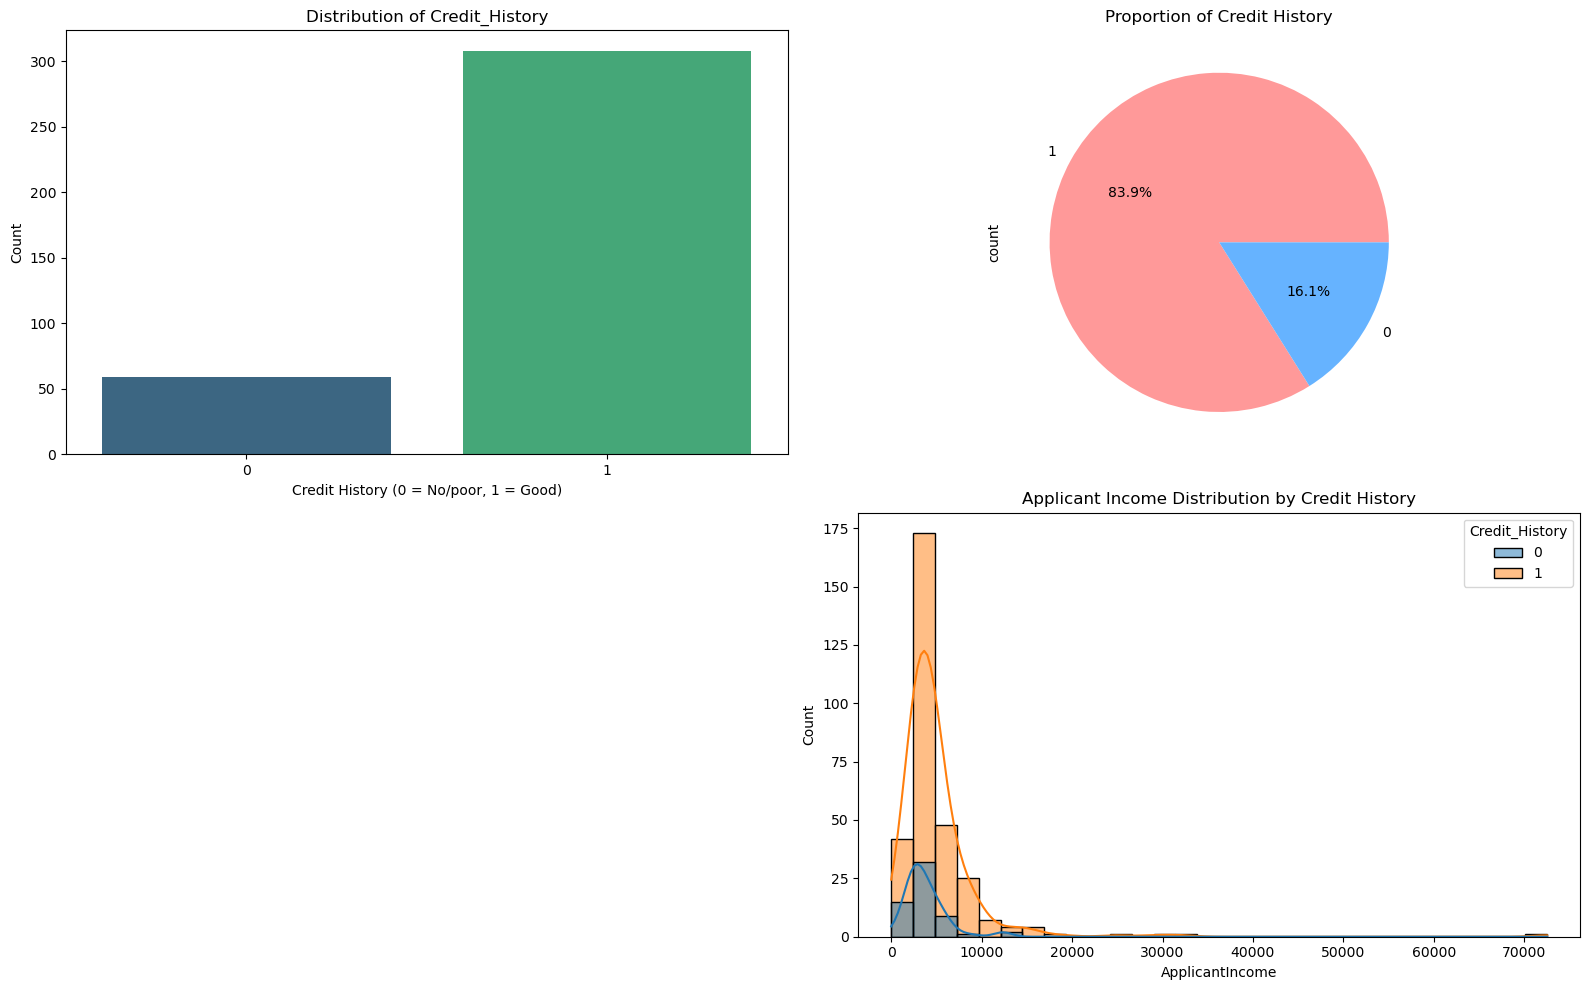

In [37]:
fig = plt.figure(figsize=(16, 10))

# Count Plot
plt.subplot(2, 2, 1)
sns.countplot(x='Credit_History', data=df_clean, palette='viridis')
plt.title('Distribution of Credit_History')
plt.xlabel('Credit History (0 = No/poor, 1 = Good)')
plt.ylabel('Count')

# Pie Chart
plt.subplot(2, 2, 2)
df_clean['Credit_History'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Proportion of Credit History')

# Boxplot with Total Income (if feature exists)
if 'Total_Income' in df_clean.columns:
    plt.subplot(2, 2, 3)
    sns.boxplot(x='Credit_History', y='Total_Income', data=df_clean)
    plt.title('Total Income by Credit History')

plt.subplot(2, 2, 4)
sns.histplot(data=df_clean, x='ApplicantIncome', hue='Credit_History', kde=True, bins=30)
plt.title('Applicant Income Distribution by Credit History')

plt.tight_layout()
plt.show()

<ipython-input-39-ff3329580bcd>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Credit_History', y=col, data=df_clean, palette='Set2')
<ipython-input-39-ff3329580bcd>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Credit_History', y=col, data=df_clean, palette='Set2')
<ipython-input-39-ff3329580bcd>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Credit_History', y=col, data=df_clean, palette='Set2')
<ipython-input-39-ff3329580bcd>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in

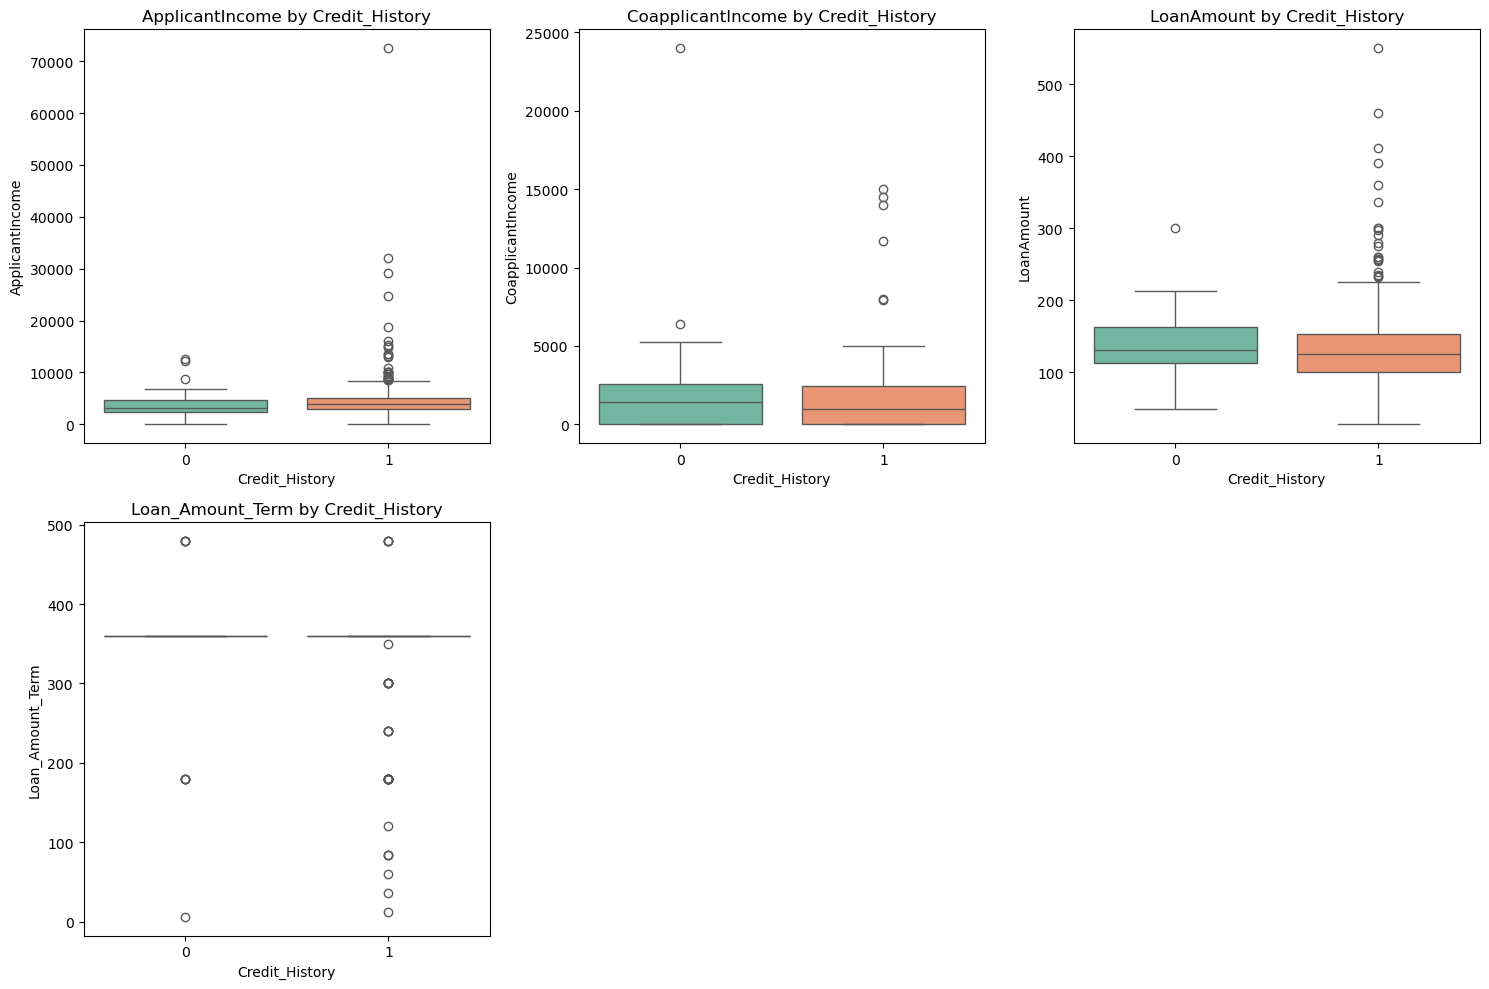

<class 'KeyError'>: "['Total_Income'] not in index"

In [39]:
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 
                 'Loan_Amount_Term', 'Total_Income']  # Add any others you created

plt.figure(figsize=(15, 10))
for i, col in enumerate([c for c in numerical_cols if c in df_clean.columns], 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Credit_History', y=col, data=df_clean, palette='Set2')
    plt.title(f'{col} by Credit_History')
plt.tight_layout()
plt.show()

# Correlation with numerical features
corr = df_clean[numerical_cols + ['Credit_History']].corr()['Credit_History'].sort_values(ascending=False)
print("\n=== Correlation with Credit_History ===")
print(corr.round(4))

<ipython-input-40-5380711dbc4c>:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=col, y='Credit_History', data=df_clean, ci=None, palette='coolwarm')
<ipython-input-40-5380711dbc4c>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Credit_History', data=df_clean, ci=None, palette='coolwarm')
<ipython-input-40-5380711dbc4c>:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=col, y='Credit_History', data=df_clean, ci=None, palette='coolwarm')
<ipython-input-40-5380711dbc4c>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=col, y='Credit_History', data=df_

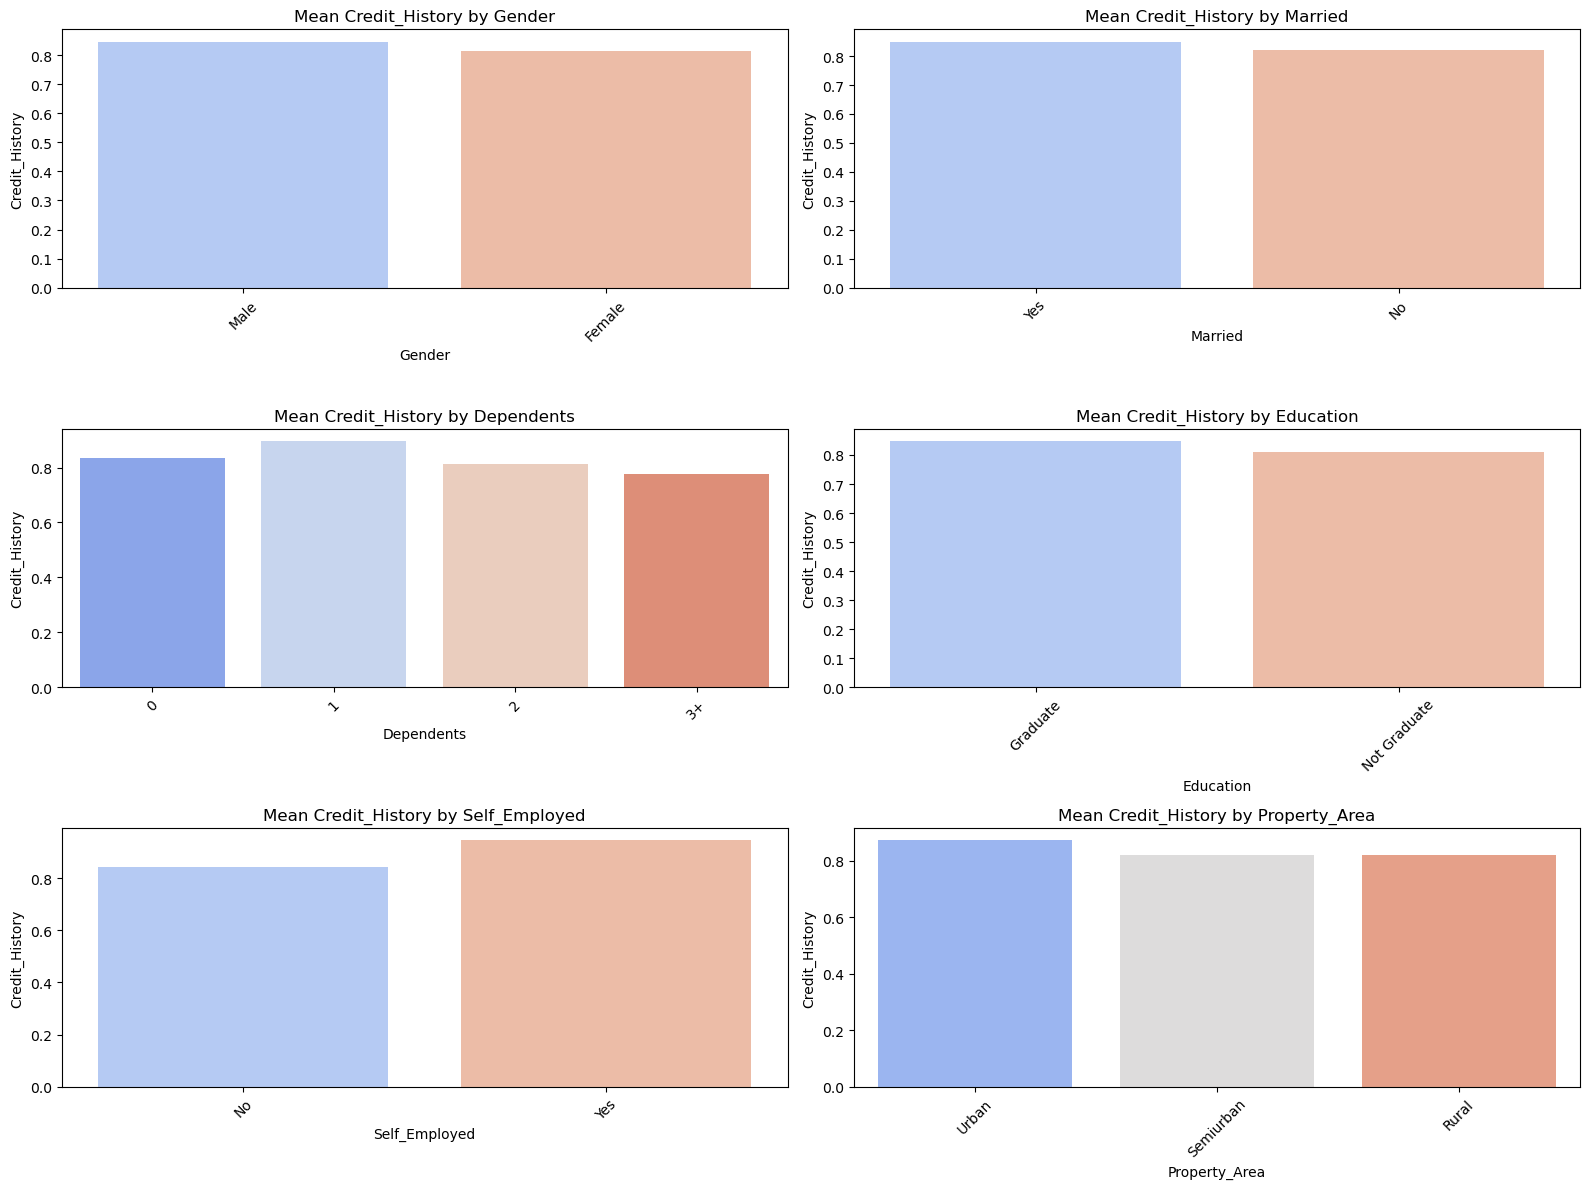

In [40]:
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 
                   'Self_Employed', 'Property_Area']

plt.figure(figsize=(16, 12))
for i, col in enumerate(categorical_cols, 1):
    if col in df_clean.columns:
        plt.subplot(3, 2, i)
        # Approval rate style if Loan_Status exists, otherwise mean
        if 'Loan_Status' in df_clean.columns:
            sns.barplot(x=col, y='Credit_History', data=df_clean, ci=None, palette='coolwarm')
            plt.title(f'Mean Credit_History by {col}')
        else:
            sns.barplot(x=col, y='Credit_History', data=df_clean, ci=None, palette='coolwarm')
            plt.title(f'Mean Credit_History by {col}')
        plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
if 'Loan_Status' in df_clean.columns:
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    sns.countplot(x='Credit_History', hue='Loan_Status', data=df_clean, palette='Set1')
    plt.title('Loan Status by Credit History')
    
    plt.subplot(1, 2, 2)
    approval_rate = df_clean.groupby('Credit_History')['Loan_Status'].value_counts(normalize=True).unstack()
    approval_rate.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())
    plt.title('Loan Approval Rate by Credit History')
    plt.ylabel('Proportion')
    plt.xticks(rotation=0)
    plt.legend(title='Loan_Status')
    plt.show()
    
    print("\n=== Loan Approval Rate by Credit History ===")
    print(df_clean.groupby('Credit_History')['Loan_Status'].value_counts(normalize=True).round(4)*100)

In [ ]:
print("\n=== Statistical Summary ===")
print(df_clean.groupby('Credit_History').describe())

# Chi-square test with categorical variables
from scipy.stats import chi2_contingency

print("\n=== Chi-Square Tests (Association with Credit_History) ===")
for col in categorical_cols:
    if col in df_clean.columns:
        contingency = pd.crosstab(df_clean['Credit_History'], df_clean[col])
        chi2, p, dof, expected = chi2_contingency(contingency)
        print(f"{col:15} → Chi2 = {chi2:.2f}, p-value = {p:.4f} {'(Significant)' if p < 0.05 else ''}")

In [ ]:
# Export summary tables
summary = pd.DataFrame({
    'Credit_History': [0, 1],
    'Count': df_clean['Credit_History'].value_counts().values,
    'Percentage': df_clean['Credit_History'].value_counts(normalize=True).values * 100
})

if 'Loan_Status' in df_clean.columns:
    approval = df_clean.groupby('Credit_History')['Loan_Status'].value_counts(normalize=True).unstack()
    summary = pd.concat([summary, approval], axis=1)

summary.to_csv('credit_history_eda_summary.csv', index=False)
print("\nEDA summary saved as 'credit_history_eda_summary.csv'")